# Week1_ex2 Analysis - Why Does Force_x Kink Around 100A?

![Model geometry](Images/Week1_ex2_result_image.png)

## 1. Expected shape

For a C-core actuator, the pulling force on the armature scales with the square of the gap flux density:

$$F \propto B_{gap}^2$$

With a permanent magnet bias plus a coil, the gap field is usually approximated as bias plus a term linear in current:

$$B_{gap} \approx B_{bias} + kI$$

$$F(I) = \frac{A}{2\mu_0}(B_{bias} + kI)^2 = \frac{A}{2\mu_0}(B_{bias}^2 + 2B_{bias}kI + k^2I^2)$$

Expanded in I this is a quadratic with all positive coefficients, so it should trace a smooth, upward-curving parabola - the slope grows steadily as current increases, with no sudden jump anywhere along the sweep.

This notebook checks that expectation against the actual Week1_ex2 sweep and works through why the two don't match. All numbers below were pulled once from the solved Week1_ex2 project; this notebook itself does not need AEDT installed to run, since it is pure post-processing of already-extracted values.

In [1]:
# 1. Import required libraries
import math
import pandas as pd
import matplotlib.pyplot as plt

## 2. Actual sweep result

Force_x is the component that matters here, since the Bar sits along +X from the Core. Force_y and Force_z stay close to zero across the whole sweep in the native AEDT plot, so they are not analyzed further.

In [2]:
# 2. FEM sweep result (Force1.Force_x), pulled once from the solved Week1_ex2 project
sweep_df = pd.DataFrame({
    "c1": ["0A", "100A", "200A", "300A", "400A", "500A"],
    "Force_x": [-0.0553583066632242, -0.157547201833921, -0.741917980286765,
                -1.35474735476014, -1.91523601946461, -2.53987110885668],
})
sweep_df

,c1,Force_x
0,0A,-0.055358
1,100A,-0.157547
2,200A,-0.741918
3,300A,-1.354747
4,400A,-1.915236
5,500A,-2.539871


In [3]:
# 3. Check how much Force_x changes between each 100A step
sweep_df["delta"] = sweep_df["Force_x"].diff()
sweep_df

,c1,Force_x,delta
0,0A,-0.055358,NaN
1,100A,-0.157547,-0.102189
2,200A,-0.741918,-0.584371
3,300A,-1.354747,-0.612829
4,400A,-1.915236,-0.560489
5,500A,-2.539871,-0.624635


## 3. Comparing to the expected shape

The quadratic model predicts a delta that grows steadily and continuously as current increases - no step should stand out from its neighbors. The actual deltas do not look like that: the 100-500A steps are all close to -0.56 to -0.62N, while the 0-100A step is only about -0.10N, roughly 6 times smaller than the rest. Instead of a smooth parabola, there is a slow start followed by a much steeper, close-to-linear climb.

Two hypotheses were checked to explain this mismatch: a more detailed magnetic circuit model, and mesh dependency in the parametric sweep.

## 4. Hypothesis 1 - Reluctance circuit model

Build a series magnetic circuit (magnet + core + air gap) with the actual material properties and geometry, and see whether the resulting F(I) curve reproduces the measured shape. This model assumes linear, uniform permeability and ignores flux leakage, so it can only be a first-pass check.

In [4]:
# 4. Bounding boxes, pulled once from the model (get_object_from_name().bounding_box)
boxes_df = pd.DataFrame({
    "object": ["Core", "Bar", "Magnet"],
    "xmin": [0.0, 51.0, 0.0], "ymin": [-40.0, -40.0, -10.0], "zmin": [-5.0, -5.0, -5.0],
    "xmax": [50.0, 61.0, 10.0], "ymax": [40.0, 40.0, 10.0], "zmax": [5.0, 5.0, 5.0],
}).set_index("object")
boxes_df

,xmin,ymin,zmin,xmax,ymax,zmax
object,,,,,,
Core,0.0,-40.0,-5.0,50.0,40.0,5.0
Bar,51.0,-40.0,-5.0,61.0,40.0,5.0
Magnet,0.0,-10.0,-5.0,10.0,10.0,5.0


In [5]:
# 5. Magnet Hc and Br, pulled once from the NdFe35 material definition
Hc = 890000.0  # A/m, from get_magnetic_coercivity()
mu_r_magnet = 1.0997785406  # from NdFe35.permeability.value
mu0 = 4 * math.pi * 1e-7
Br = mu0 * mu_r_magnet * Hc

pd.DataFrame({"Hc (A/m)": [Hc], "Br (T)": [Br]})

,Hc (A/m),Br (T)
0,890000.0,1.23


In [6]:
# 6. Set up the magnetic circuit dimensions (air gap is where Core meets Bar)
l_gap = (boxes_df.loc["Bar", "xmin"] - boxes_df.loc["Core", "xmax"]) * 1e-3  # mm to m
A_gap = 2 * (10e-3 * 10e-3)                                                    # two 10x10mm strips where the yokes face the bar
l_magnet = (boxes_df.loc["Magnet", "ymax"] - boxes_df.loc["Magnet", "ymin"]) * 1e-3  # magnet thickness along the magnetization axis
A_magnet = 10e-3 * 10e-3
l_core = 0.15                                                # rough flux path length, not measured precisely
A_core = 10e-3 * 10e-3
mu_r_core = 1000                                             # steel_1008 is actually nonlinear, this is a rough linear stand-in

R_gap = l_gap / (mu0 * A_gap)
R_magnet = l_magnet / (mu0 * mu_r_magnet * A_magnet)
R_core = l_core / (mu0 * mu_r_core * A_core)
R_total = R_gap + R_magnet + R_core

MMF_magnet = Hc * l_magnet
N = 1  # coil is a single-turn solid, not a wound winding

def theory_force(c1_amps):
    MMF_net = MMF_magnet + N * c1_amps
    phi = MMF_net / R_total
    B_gap = phi / A_gap
    return (B_gap ** 2 * A_gap) / (2 * mu0)

compare_df = sweep_df[["c1", "Force_x"]].copy()
compare_df["c1_numeric"] = compare_df["c1"].str.replace("A", "").astype(float)
compare_df["Force_theory"] = compare_df["c1_numeric"].apply(theory_force)
compare_df[["c1", "Force_x", "Force_theory"]]

,c1,Force_x,Force_theory
0,0A,-0.055358,28.056696
1,100A,-0.157547,28.372825
2,200A,-0.741918,28.690725
3,300A,-1.354747,29.010397
4,400A,-1.915236,29.331839
5,500A,-2.539871,29.655052


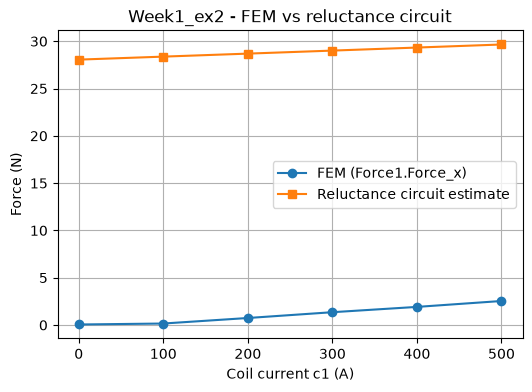

In [7]:
# 7. Plot FEM vs theory side by side
plt.figure(figsize=(6, 4))
plt.plot(compare_df["c1_numeric"], compare_df["Force_x"].abs(), marker="o", label="FEM (Force1.Force_x)")
plt.plot(compare_df["c1_numeric"], compare_df["Force_theory"], marker="s", label="Reluctance circuit estimate")
plt.xlabel("Coil current c1 (A)")
plt.ylabel("Force (N)")
plt.title("Week1_ex2 - FEM vs reluctance circuit")
plt.legend()
plt.grid(True)
plt.savefig("Images/Week1_ex2_force_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Hypothesis 1 rejected

The reluctance circuit predicts a force about 12x larger than FEM at every current point, and the predicted curve is nearly flat instead of curving upward - the magnet's MMF (about 17800 A) completely dominates the coil's MMF (max 500 A with a single-turn coil), so this model says current should barely move the force at all.

Pulling steel_1008's permeability from the material library shows it is stored as a full B-H curve, not a constant - so the linear, single-value permeability this circuit assumes was never a good fit for this material to begin with. The circuit model is too simplified to explain either the size or the shape of the FEM curve.

## 5. Hypothesis 2 - Mesh dependency

The original sweep uses `CopyMesh: True` and `SolveWithCopiedMeshOnly: True`, reusing the adaptive mesh generated at the nominal 100A setup for every other current in the sweep. If that nominal mesh happens to fit the field distribution better near 100A than near 0A, it could produce an artificial slowdown at low current that has nothing to do with the actual physics.

`Week1_ex2_mesh_verification.ipynb` reruns the identical model with `CopyMesh: False`, so every point gets its own independent adaptive mesh. The comparison below was pulled once from that companion notebook.

In [8]:
# 8. Mesh reuse vs independent mesh, pulled once from Week1_ex2_mesh_verification.ipynb
mesh_df = pd.DataFrame({
    "c1": ["0A", "100A", "200A", "300A", "400A", "500A"],
    "original_mesh_reuse": [-0.05536, -0.15755, -0.74192, -1.35475, -1.91524, -2.53987],
    "independent_mesh": [-0.05536, -0.12527, -0.56906, -1.10896, -1.70034, -2.13288],
})
mesh_df["delta_original"] = mesh_df["original_mesh_reuse"].diff()
mesh_df["delta_independent"] = mesh_df["independent_mesh"].diff()
mesh_df

,c1,original_mesh_reuse,independent_mesh,delta_original,delta_independent
0,0A,-0.05536,-0.05536,NaN,NaN
1,100A,-0.15755,-0.12527,-0.10219,-0.06991
2,200A,-0.74192,-0.56906,-0.58437,-0.44379
3,300A,-1.35475,-1.10896,-0.61283,-0.53990
4,400A,-1.91524,-1.70034,-0.56049,-0.59138
5,500A,-2.53987,-2.13288,-0.62463,-0.43254


Slope ratio (100-500A average slope / 0-100A slope): 5.83x with mesh reuse, 7.18x with independent mesh.

![Mesh reuse vs independent mesh](Images/Week1_ex2_mesh_comparison.png)

## Hypothesis 2 rejected

Independent meshing does not remove the slowdown between 0A and 100A - if anything the ratio between the two slope regions is larger with independent mesh than with mesh reuse. Mesh reuse was not creating the kink; it was mildly softening it.

## 6. Final explanation - competing flux paths

Looking at the geometry again: the Core forms one closed steel loop by itself (magnet leg - top yoke - coil leg - bottom yoke), and only the far end of each yoke (x=50) faces the Bar across the 1mm air gap. That gives the magnet's flux two paths to choose from - stay inside the all-steel loop, or cross the gap into the Bar. The reluctance circuit in section 4 only modeled the gap path and assumed all of the magnet's flux takes it, which is why it overestimated the force so badly.

Two probes were added to the solved project to check this directly: one in the middle of a yoke, away from the gap (the internal loop), and one right at the gap-facing end of the same yoke.

In [9]:
# 9. Internal-loop vs gap field values, pulled once from the solved project
# after adding a MainLoopProbe point (mid-yoke) and a GapProbe point (yoke end, facing the Bar)
flux_df = pd.DataFrame({
    "c1": ["0A", "100A", "200A", "300A", "500A"],
    "main_loop_B": [1.170273, 1.228558, 1.269662, 1.296553, 1.328961],
    "gap_B": [0.016922, 0.028424, 0.061587, 0.083152, 0.113912],
})
flux_df["gap_to_main_loop_ratio"] = flux_df["gap_B"] / flux_df["main_loop_B"]
flux_df

,c1,main_loop_B,gap_B,gap_to_main_loop_ratio
0,0A,1.170273,0.016922,0.014460
1,100A,1.228558,0.028424,0.023136
2,200A,1.269662,0.061587,0.048507
3,300A,1.296553,0.083152,0.064133
4,500A,1.328961,0.113912,0.085715


## Conclusion

- The internal loop is already carrying about 1.17T from the magnet alone at 0A, and only rises to about 1.33T by 500A - the core is close to saturated on this path even before the coil turns on.
- The gap/internal-loop ratio grows from 0.0145 at 0A to 0.0857 at 500A, almost a 6x increase. At 0A, over 98% of the magnet's flux stays inside the all-steel loop and barely reaches the Bar, matching why Force_x is nearly zero there.
- As coil current increases, it raises the reluctance of the coil-side leg just enough to push a growing share of the magnet's flux out through the gap instead. That reallocation between two competing paths - not a meshing artifact - produces the slow start below 100A and the much faster rise above it.
- The quadratic relationship from section 1 is not wrong on its own terms - force still scales with B_gap squared - but the assumption that B_gap grows linearly with current (bias plus kI) breaks down here, since B_gap actually depends on how flux is split between the internal loop and the gap, and that split shifts nonlinearly as the core nears saturation.
- Overall, the kink is a real physical effect from a two-path magnetic circuit combined with the core sitting close to saturation, not a numerical artifact from meshing or an error in the FEM setup.